# Un satélite ve temperatura. ¿Puede ver las corrientes del océano?

Las corrientes submesoscale (1 a 10 km) dominan cómo el océano mezcla calor, nutrientes y CO₂ entre la superficie y las profundidades. El problema: son demasiado finas para los satélites que miden altimetría — y medirlas con simulaciones globales cuesta millones de horas de cómputo.

Un equipo de Scripps entrenó una red neuronal — **GOFLOW** — que aprende a inferir el campo de velocidad superficial a partir de tres imágenes consecutivas de temperatura. En este notebook abrimos sus datos públicos y verificamos cuánto del campo real logra reconstruir.

**Paper**: [Lenain et al. (2026), *Nature Geoscience*](https://doi.org/10.1038/s41561-026-01943-0)
**Datos**: [Zenodo 15815704](https://doi.org/10.5281/zenodo.15815704)
**Código original**: [github.com/ksr-ocean/goflow](https://github.com/ksr-ocean/goflow)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-13-goflow-corrientes-submesoscale/notebook.ipynb)

## Qué estamos mirando

El equipo entrenó una U-Net (una red neuronal convolucional tipo encoder-decoder) con un año de datos horarios del modelo oceánico **LLC4320** (una simulación global de ~2 km de resolución). La red recibe tres snapshots consecutivos del gradiente de temperatura superficial — separados por una hora — y devuelve el campo de velocidad superficial (u, v) en el instante central.

Los datos públicos en Zenodo contienen el **test set filtrado** (un subconjunto separado del entrenamiento, con un filtro pasa-bajos Butterworth de 18 horas para eliminar mareas): 41 snapshots de 256×256 píxeles en la región del Gulf Stream. Para cada píxel tenemos la velocidad real (LLC4320) y la predicha (GOFLOW).

Empezamos por los campos derivados — vorticidad, divergencia y deformación — porque ahí se juega el contenido submesoscale.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SNAPSHOT_HERO = 40          # Snapshot a mostrar en la gráfica hero (r_vort más alto)
COLOR_TRUTH = '#2563EB'     # Azul CaM — LLC4320 (verdad)
COLOR_PRED = '#DC2626'      # Rojo — GOFLOW (predicción)
COLOR_DIFF = '#7C3AED'      # Violeta — error
FUENTE = 'Fuente: Lenain et al. (2026), Nature Geoscience | Datos: Zenodo 15815704'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM — local primero, fallback a raw GitHub
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga — 4 CSVs agregados en el servidor desde el raw de Zenodo (113 MB)
stats_df = pd.read_csv('datos/estadisticas_campos.csv')
pdf_df = pd.read_csv('datos/pdf_campos.csv')
corr_df = pd.read_csv('datos/correlacion_por_snapshot.csv')
snap_df = pd.read_csv('datos/snapshot_representativo.csv')

print(f'Estadísticas globales: {len(stats_df)} filas (3 variables × 2 fuentes)')
print(f'PDFs: {len(pdf_df)} filas (80 bins × 3 variables × 2 fuentes)')
print(f'Correlación por snapshot: {len(corr_df)} filas ({corr_df["snapshot"].nunique()} snapshots × 5 variables)')
print(f'Snapshot representativo t={SNAPSHOT_HERO}: {len(snap_df)} píxeles (128×128, downsampled)')
print(f'n píxeles por variable en las estadísticas globales: {stats_df["n"].iloc[0]:,}'.replace(',', '.'))

Estadísticas globales: 6 filas (3 variables × 2 fuentes)
PDFs: 240 filas (80 bins × 3 variables × 2 fuentes)
Correlación por snapshot: 205 filas (41 snapshots × 5 variables)
Snapshot representativo t=40: 16384 píxeles (128×128, downsampled)
n píxeles por variable en las estadísticas globales: 2.686.976


## Aquí está.

El snapshot *t* = 40 del test set — elegido porque es donde GOFLOW alcanza su mejor correlación en vorticidad (*r* = 0,78). A la izquierda, el gradiente de temperatura superficial que ve el satélite. En el centro, la vorticidad real del modelo LLC4320. A la derecha, la que predice GOFLOW a partir de los tres snapshots térmicos.

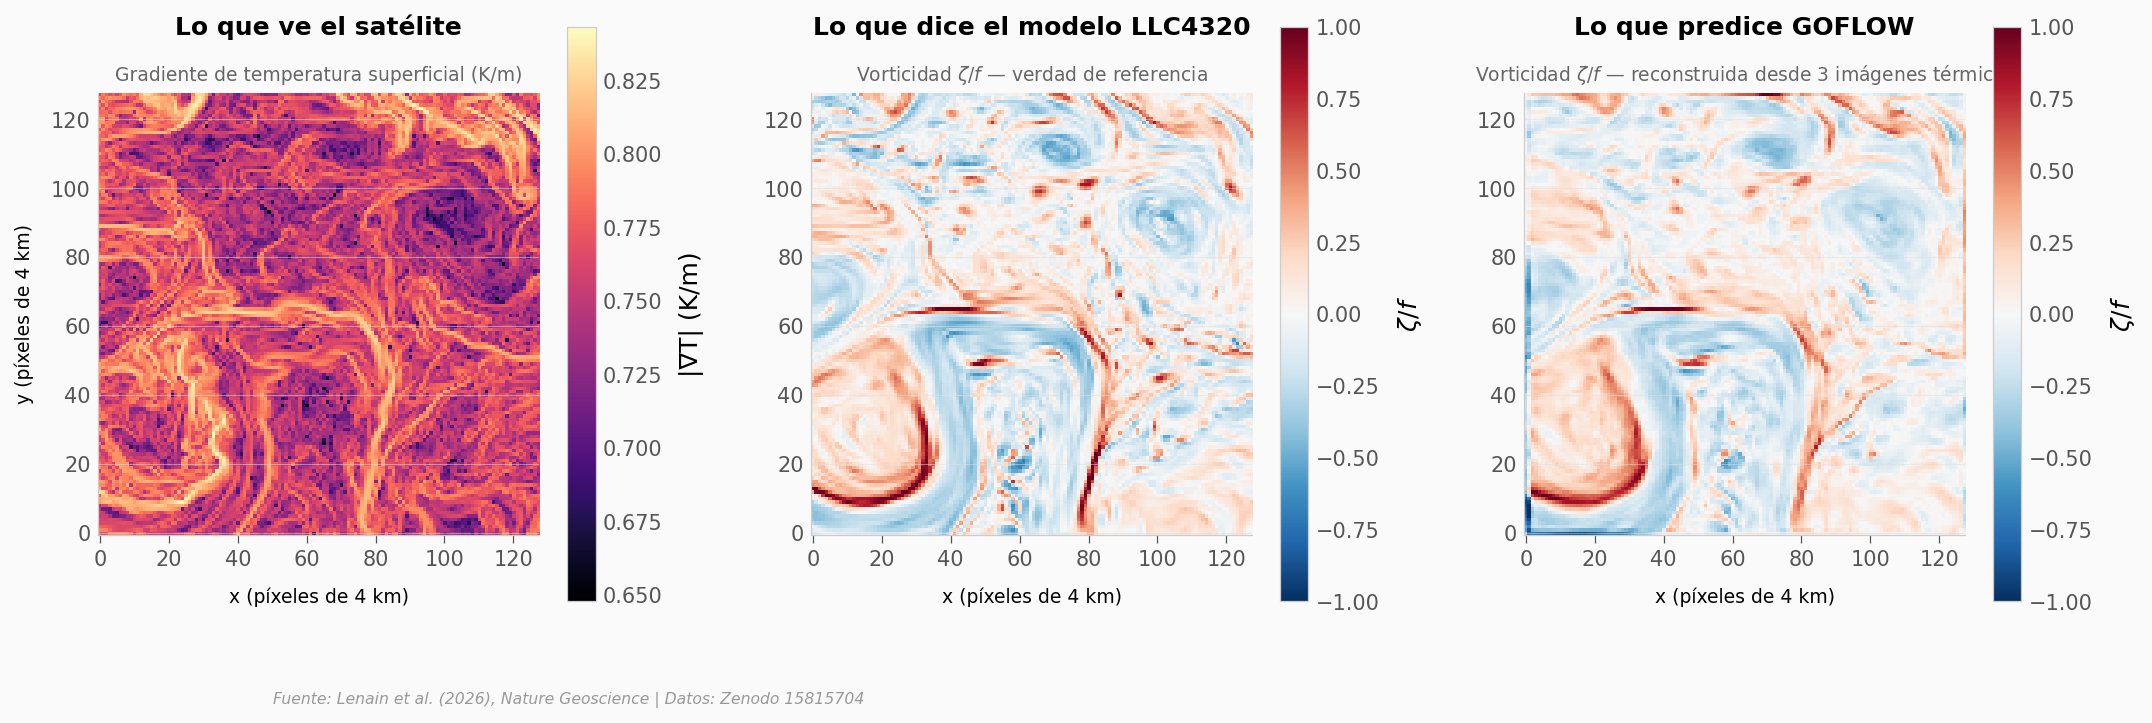

Correlación Pearson de vorticidad en este snapshot: r = 0.785


In [2]:
# Reshape a grid 128×128 para imshow
dim = int(np.sqrt(len(snap_df)))
gradT = snap_df['gradT_sst'].values.reshape(dim, dim)
vort_truth = snap_df['vort_llc4320_zeta_f'].values.reshape(dim, dim)
vort_pred = snap_df['vort_goflow_zeta_f'].values.reshape(dim, dim)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 5))

# Panel 1: SST gradient (input del satélite)
im0 = axes[0].imshow(gradT, cmap='magma', origin='lower', aspect='equal')
axes[0].set_title('Lo que ve el satélite',
                  fontsize=12, fontweight='bold', pad=28)
axes[0].text(0.5, 1.03, 'Gradiente de temperatura superficial (K/m)',
             transform=axes[0].transAxes, fontsize=9, color='#666666', ha='center')
axes[0].set_xlabel('x (píxeles de 4 km)', fontsize=9)
axes[0].set_ylabel('y (píxeles de 4 km)', fontsize=9)
plt.colorbar(im0, ax=axes[0], shrink=0.82, label='|∇T| (K/m)')

# Panel 2: Vorticidad verdad
vmax = 1.0  # saturación común para comparar
im1 = axes[1].imshow(vort_truth, cmap='RdBu_r', origin='lower',
                    vmin=-vmax, vmax=vmax, aspect='equal')
axes[1].set_title('Lo que dice el modelo LLC4320',
                  fontsize=12, fontweight='bold', pad=28)
axes[1].text(0.5, 1.03, r'Vorticidad $\zeta/f$ — verdad de referencia',
             transform=axes[1].transAxes, fontsize=9, color='#666666', ha='center')
axes[1].set_xlabel('x (píxeles de 4 km)', fontsize=9)
plt.colorbar(im1, ax=axes[1], shrink=0.82, label=r'$\zeta/f$')

# Panel 3: Vorticidad GOFLOW
im2 = axes[2].imshow(vort_pred, cmap='RdBu_r', origin='lower',
                    vmin=-vmax, vmax=vmax, aspect='equal')
axes[2].set_title('Lo que predice GOFLOW',
                  fontsize=12, fontweight='bold', pad=28)
axes[2].text(0.5, 1.03, r'Vorticidad $\zeta/f$ — reconstruida desde 3 imágenes térmicas',
             transform=axes[2].transAxes, fontsize=9, color='#666666', ha='center')
axes[2].set_xlabel('x (píxeles de 4 km)', fontsize=9)
plt.colorbar(im2, ax=axes[2], shrink=0.82, label=r'$\zeta/f$')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/hero_vorticidad_sst.png', dpi=200, bbox_inches='tight')
plt.show()

# Verificar r en este snapshot
r_snap, _ = stats.pearsonr(snap_df['vort_llc4320_zeta_f'], snap_df['vort_goflow_zeta_f'])
print(f'Correlación Pearson de vorticidad en este snapshot: r = {r_snap:.3f}')

Los remolinos intensos — los filamentos rojos y azules alargados — reaparecen casi en la misma posición en la predicción. La asimetría que hace reconocible al régimen submesoscale (remolinos ciclónicos, los rojos, más intensos que los anticiclónicos) se conserva.

Lo que cambia: la amplitud. GOFLOW empuja los picos más suaves, como si estuviera viendo una foto ligeramente desenfocada. Esa pérdida de varianza es un hallmark conocido de las reconstrucciones hechas por U-Nets: aprenden la estructura, pero promedian el detalle extremo.

Lo que sí se conserva — y es lo que importa para estimar flujos verticales — son las *posiciones* y *orientaciones* de los frentes. Ahí es donde se juega la física.

## Pero no todas las variables son iguales

La vorticidad no es la única derivada del campo de velocidad que importa. También hay divergencia (δ/f — qué tan rápido el agua se separa o se junta, un proxy para movimientos verticales) y deformación (α/f — cuánto la corriente estira y comprime). Cada una mide algo distinto, y GOFLOW no las reconstruye con la misma fidelidad.

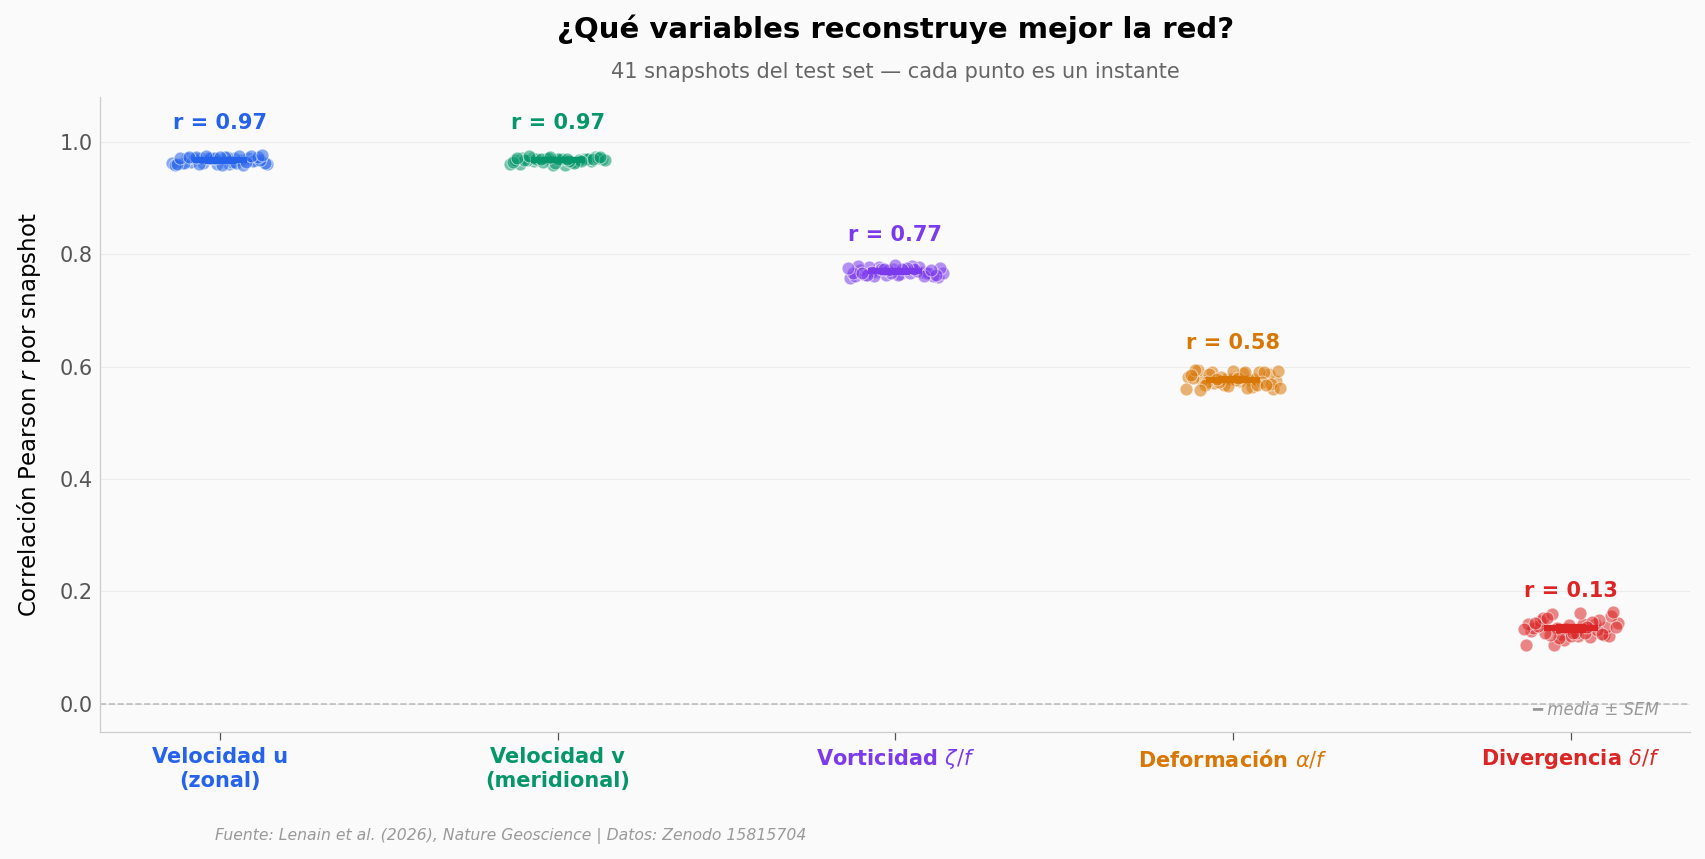

u_m_s                                     r media = 0.967   min = 0.958   max = 0.976
v_m_s                                     r media = 0.968   min = 0.958   max = 0.975
vorticidad_zeta_sobre_f                   r media = 0.769   min = 0.758   max = 0.780
deformacion_alpha_sobre_f                 r media = 0.577   min = 0.558   max = 0.594
divergencia_delta_sobre_f                 r media = 0.134   min = 0.104   max = 0.162


In [3]:
# Re-etiquetar variables a nombres legibles y ordenar por correlación media
etiquetas = {
    'u_m_s': 'Velocidad u\n(zonal)',
    'v_m_s': 'Velocidad v\n(meridional)',
    'vorticidad_zeta_sobre_f': r'Vorticidad $\zeta/f$',
    'deformacion_alpha_sobre_f': r'Deformación $\alpha/f$',
    'divergencia_delta_sobre_f': r'Divergencia $\delta/f$',
}
orden = ['u_m_s', 'v_m_s', 'vorticidad_zeta_sobre_f',
         'deformacion_alpha_sobre_f', 'divergencia_delta_sobre_f']
colores = ['#2563EB', '#059669', '#7C3AED', '#D97706', '#DC2626']

fig, ax = plt.subplots(figsize=(11.5, 5.5))

np.random.seed(42)
for i, var in enumerate(orden):
    subset = corr_df[corr_df['variable'] == var]['correlacion'].values
    n = len(subset)
    x_jitter = np.linspace(i - 0.14, i + 0.14, n)
    np.random.shuffle(x_jitter)
    ax.scatter(x_jitter, subset, color=colores[i], s=38, alpha=0.55,
               edgecolors='white', linewidths=0.5, zorder=5)
    media = subset.mean()
    sem = subset.std(ddof=1) / np.sqrt(n)
    ax.errorbar(i, media, yerr=sem, fmt='_', color=colores[i],
                markersize=26, markeredgewidth=3,
                capsize=7, capthick=1.5, zorder=6)
    # Etiqueta del valor medio
    ax.text(i, media + 0.055, f'r = {media:.2f}', ha='center', fontsize=10,
            fontweight='bold', color=colores[i])

ax.set_xticks(range(len(orden)))
ax.set_xticklabels([etiquetas[v] for v in orden], fontsize=10, fontweight='bold')
for tick, c in zip(ax.get_xticklabels(), colores):
    tick.set_color(c)

ax.axhline(y=0, color='#999999', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_ylabel(r'Correlación Pearson $r$ por snapshot', fontsize=11)
ax.set_ylim(-0.05, 1.08)
ax.set_title('¿Qué variables reconstruye mejor la red?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '41 snapshots del test set — cada punto es un instante',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/correlacion_por_variable.png', dpi=200, bbox_inches='tight')
plt.show()

# Reportar stats para lectura guiada
for var in orden:
    subset = corr_df[corr_df['variable'] == var]['correlacion']
    print(f'{var:40s}  r media = {subset.mean():.3f}   min = {subset.min():.3f}   max = {subset.max():.3f}')

El ranking es elocuente: las velocidades (*u*, *v*) tienen una correlación de 0,97 — casi idéntica a la verdad. La vorticidad cae a 0,77 (moderada-alta), la deformación a 0,58 (moderada), y la divergencia se desploma a **0,13** — apenas mejor que azar.

Los autores lo admiten: "δ/f is somewhat less accurately reproduced". Pero esto tiene un lado bueno: ninguna medición satelital estándar (altimetría, scatterometría) puede estimar divergencia superficial *en absoluto* — por construcción geostrófica. Que GOFLOW la estime, aun con correlación baja, ya es un avance.

Veamos ahora las distribuciones. La asimetría de las PDFs es el hallmark submesoscale que el paper asegura haber capturado.

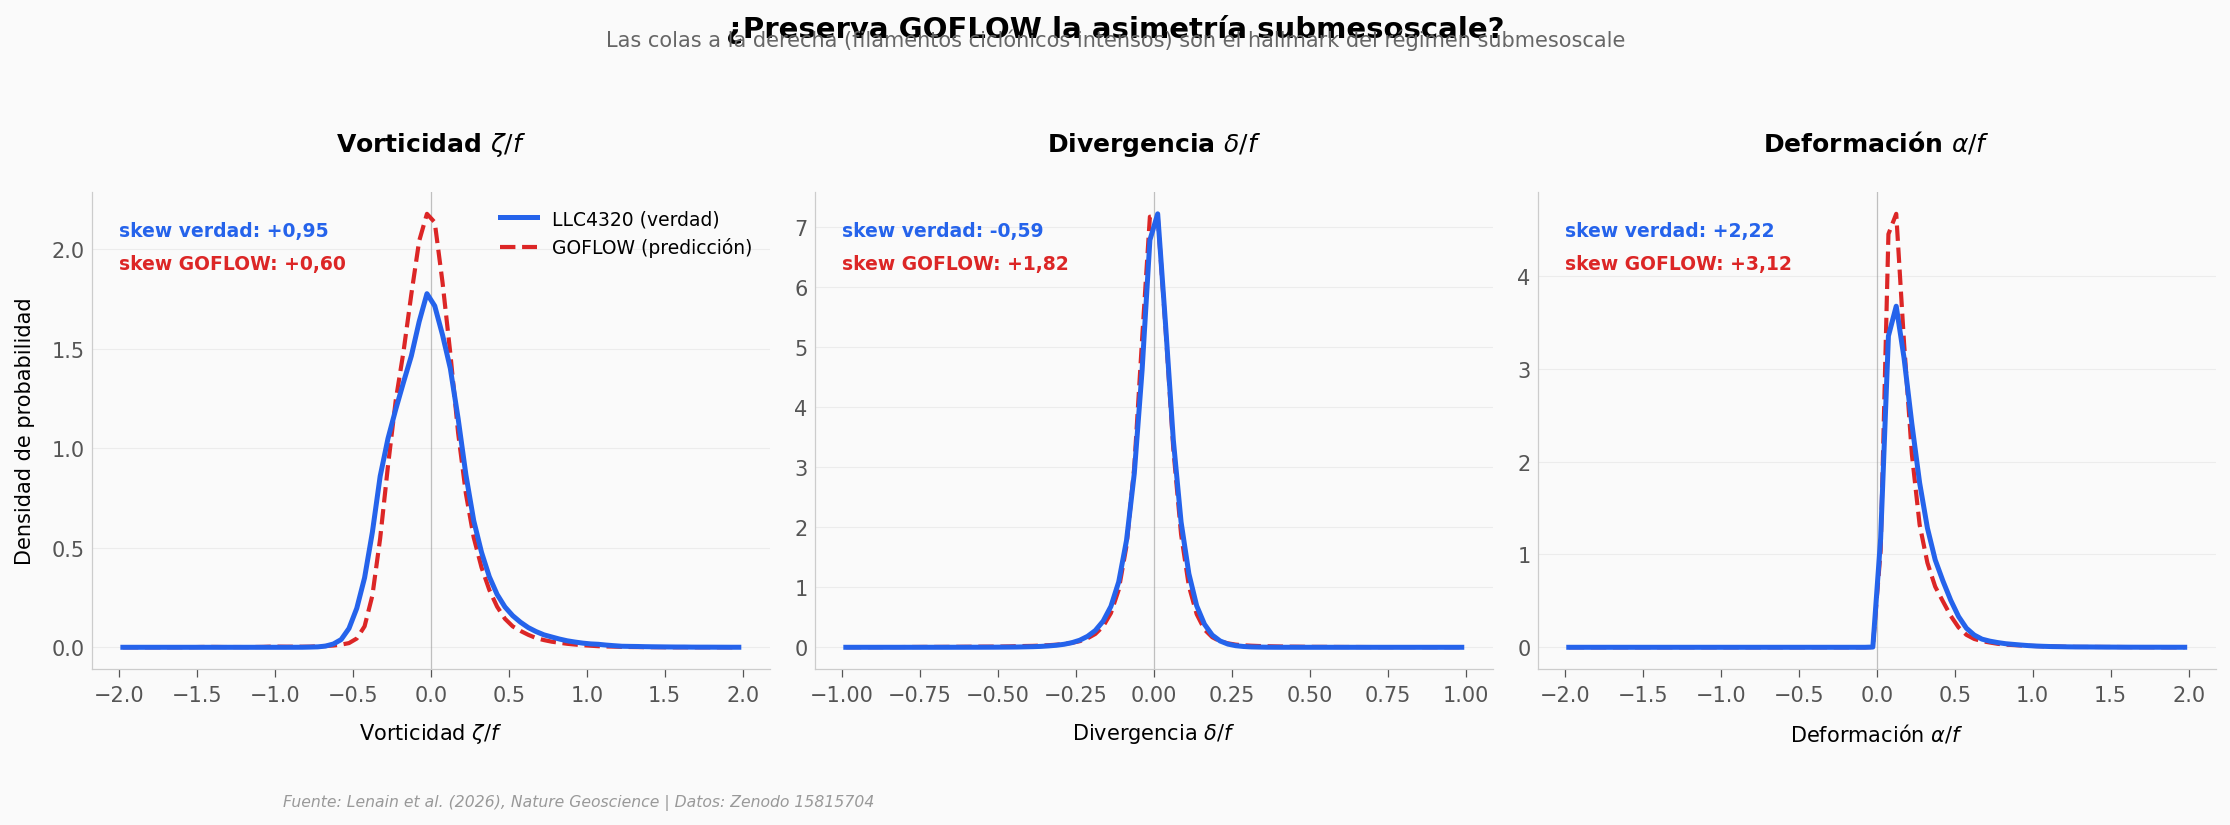

In [4]:
# Tres subplots — uno por variable derivada
vars_pdf = [
    ('vorticidad_zeta_sobre_f', r'Vorticidad $\zeta/f$',
     '+0,95', '+0,60'),
    ('divergencia_delta_sobre_f', r'Divergencia $\delta/f$',
     '-0,59', '+1,82'),
    ('deformacion_alpha_sobre_f', r'Deformación $\alpha/f$',
     '+2,22', '+3,12'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for i, (var, label, sk_truth, sk_pred) in enumerate(vars_pdf):
    sub = pdf_df[pdf_df['variable'] == var].sort_values('bin_centro')
    axes[i].plot(sub['bin_centro'], sub['pdf_llc4320'], color=COLOR_TRUTH,
                 linewidth=2.4, label='LLC4320 (verdad)', zorder=5)
    axes[i].plot(sub['bin_centro'], sub['pdf_goflow'], color=COLOR_PRED,
                 linewidth=2.0, linestyle='--', label='GOFLOW (predicción)', zorder=4)
    axes[i].axvline(x=0, color='#999999', linewidth=0.6, alpha=0.6)
    axes[i].set_xlabel(label, fontsize=10)
    axes[i].set_ylabel('Densidad de probabilidad' if i == 0 else '', fontsize=10)
    axes[i].set_title(label, fontsize=12, fontweight='bold', pad=20)
    # Anotación del skewness
    axes[i].text(0.04, 0.94, f'skew verdad: {sk_truth}', transform=axes[i].transAxes,
                 fontsize=9, color=COLOR_TRUTH, fontweight='bold', va='top')
    axes[i].text(0.04, 0.87, f'skew GOFLOW: {sk_pred}', transform=axes[i].transAxes,
                 fontsize=9, color=COLOR_PRED, fontweight='bold', va='top')

axes[0].legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.suptitle('¿Preserva GOFLOW la asimetría submesoscale?',
             fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.005, 'Las colas a la derecha (filamentos ciclónicos intensos) son el hallmark del régimen submesoscale',
         ha='center', fontsize=10, color='#666666')
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.tight_layout()
plt.savefig('figuras/pdfs_asimetria.png', dpi=200, bbox_inches='tight')
plt.show()

Para la vorticidad la asimetría se mantiene: ambas curvas se inclinan hacia la derecha (más probabilidad de valores positivos intensos que negativos). Para la deformación, GOFLOW incluso exagera la cola positiva — pero la deformación es por definición no negativa, así que la asimetría positiva no es opcional.

La divergencia es otra historia. La verdad tiene skewness **negativo** (-0,59 — lo esperado: los filamentos de convergencia son más intensos que los de divergencia, porque el agua superficial tiende a hundirse). En el test set filtrado, GOFLOW devuelve skewness **positivo** (+1,82). El signo se invierte. El paper admite esta limitación para el análisis completo; aquí lo vemos explícito en los datos públicos — el signo se invierte.

## ¿Qué tan consistente es GOFLOW snapshot a snapshot?

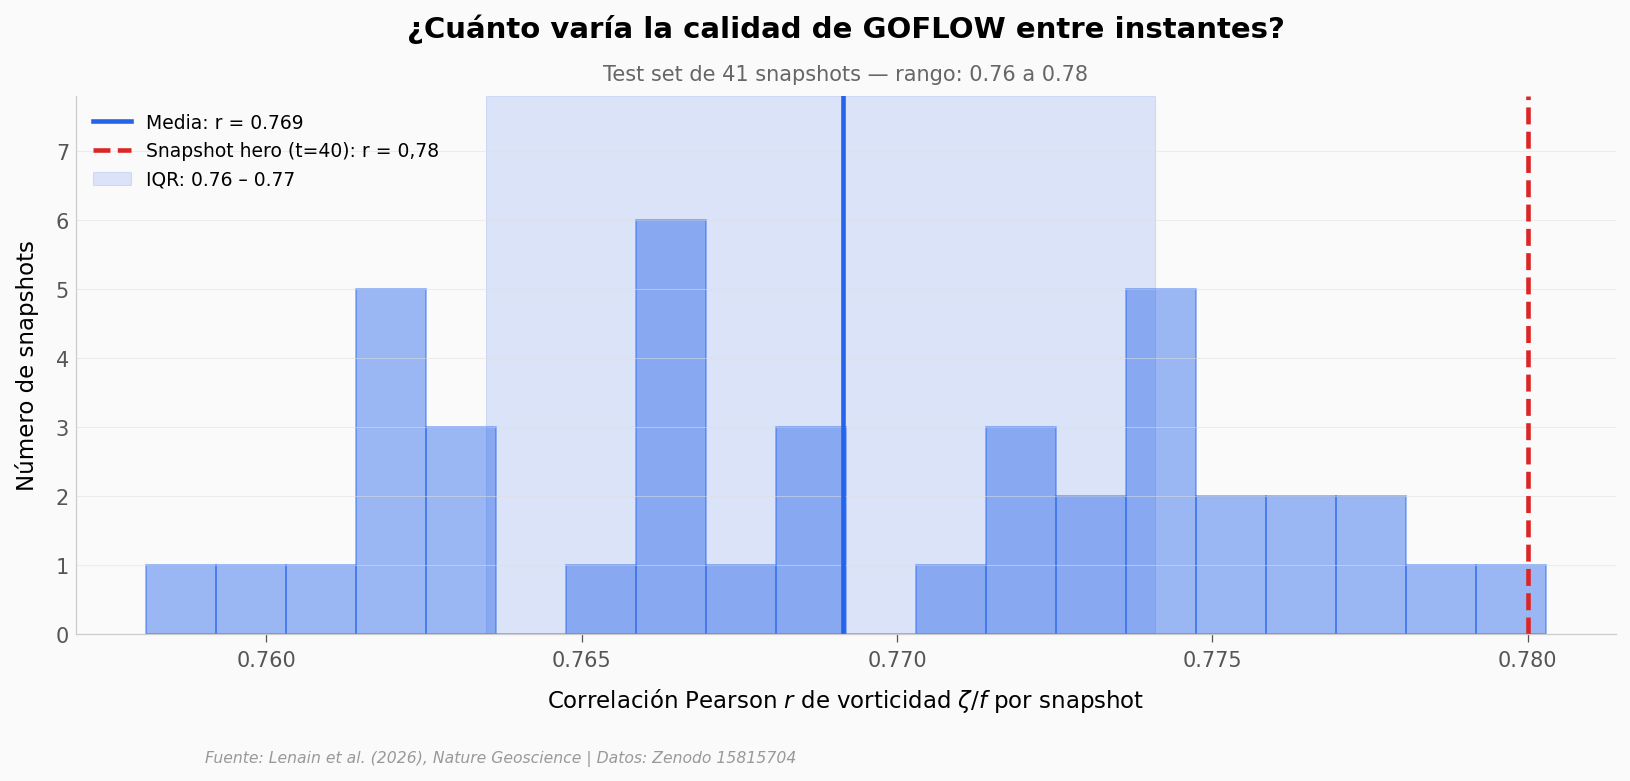

Distribución de r para vorticidad en 41 snapshots:
  media   = 0.769
  mediana = 0.769
  IQR     = [0.763, 0.774]
  rango   = [0.758, 0.780]


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

vort_corrs = corr_df[corr_df['variable'] == 'vorticidad_zeta_sobre_f']['correlacion'].values
media = vort_corrs.mean()
minimo = vort_corrs.min()
maximo = vort_corrs.max()
q25, q75 = np.percentile(vort_corrs, [25, 75])

n, bins, patches = ax.hist(vort_corrs, bins=20, color=COLOR_TRUTH, alpha=0.45,
                           edgecolor=COLOR_TRUTH, linewidth=0.9)
y_max = n.max() * 1.3
ax.set_ylim(0, y_max)

# Líneas: media del test set y snapshot hero
ax.axvline(x=media, color=COLOR_TRUTH, linewidth=2.2,
           label=f'Media: r = {media:.3f}')
ax.axvline(x=0.78, color=COLOR_PRED, linewidth=2.2, linestyle='--',
           label=f'Snapshot hero (t=40): r = 0,78')

# Sombrea IQR
ax.axvspan(q25, q75, alpha=0.15, color=COLOR_TRUTH, zorder=0,
           label=f'IQR: {q25:.2f} – {q75:.2f}')

ax.set_xlabel(r'Correlación Pearson $r$ de vorticidad $\zeta/f$ por snapshot', fontsize=11)
ax.set_ylabel('Número de snapshots', fontsize=11)
ax.set_title('¿Cuánto varía la calidad de GOFLOW entre instantes?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Test set de {len(vort_corrs)} snapshots — rango: {minimo:.2f} a {maximo:.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/histograma_correlacion_vort.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Distribución de r para vorticidad en {len(vort_corrs)} snapshots:')
print(f'  media   = {media:.3f}')
print(f'  mediana = {np.median(vort_corrs):.3f}')
print(f'  IQR     = [{q25:.3f}, {q75:.3f}]')
print(f'  rango   = [{minimo:.3f}, {maximo:.3f}]')

## Lo que los datos soportan

| Afirmación del paper | ¿Soportada? | Detalle |
|---|---|---|
| GOFLOW reconstruye velocidades con alta fidelidad | ✅ | *r* medio = 0,967 (u) y 0,968 (v); n = 41 snapshots |
| Preserva la asimetría positiva de la vorticidad | ✅ | skew verdad = +0,95 · skew predicción = +0,60 — mismo signo, asimetría conservada |
| Vorticidad reconstruida con correlación moderada-alta | ✅ | *r* medio = 0,77 (IQR 0,76–0,77) · varianza ligeramente reducida (-17%) |
| Reconstrucción de divergencia es menos precisa | ⚠️ | El paper lo enmarca como limitación ("somewhat less accurately reproduced"). En este subset filtrado 18h: *r* = 0,13, skew invertido (+1,82 vs -0,59) |
| Deformación reconstruida con calidad razonable | ✅ | *r* medio = 0,58, skew positivo preservado (+2,22 → +3,12) |

> **Limitaciones del análisis:**
> - El test set publicado está filtrado con pasa-bajos Butterworth de 18 h (elimina marea). El análisis espectral completo del paper (Extended Data Fig. 6) puede diferir en los detalles finos de la divergencia.
> - El entrenamiento usó 1 año de datos en el Atlántico (20–45°N); el rendimiento en otras regiones (e.g. el Austral, con frentes distintos) no está verificado aquí.
> - LLC4320 no resuelve completamente lo sub-kilómetro, así que la "verdad" misma es una aproximación del océano real.
> - La correlación es Pearson punto a punto. No penaliza desplazamientos espaciales pequeños: si GOFLOW acierta la estructura pero la mueve 2 km, *r* baja aunque el campo sea casi correcto.

## Ahora tú

Los datos están cargados — tres líneas y exploras algo distinto:

1. ¿En qué snapshot funciona peor GOFLOW para vorticidad? ¿Qué tienen en común esos snapshots?
   *Pista:* `corr_df[corr_df['variable'] == 'vorticidad_zeta_sobre_f'].nsmallest(5, 'correlacion')`

2. ¿La correlación de divergencia y vorticidad están relacionadas entre snapshots? Si GOFLOW falla en una, ¿falla en las dos?
   *Pista:* pivota `corr_df` por variable y corre `stats.spearmanr()`.

3. ¿Qué tan lineal es la relación entre GOFLOW y LLC4320 para divergencia en el snapshot hero?
   *Pista:* `stats.pearsonr(snap_df['div_llc4320_delta_f'], snap_df['div_goflow_delta_f'])`. Compara con la vorticidad en el mismo snapshot.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿fallan juntas vorticidad y divergencia?

pivot = corr_df.pivot(index='snapshot', columns='variable', values='correlacion')
rho, pval = stats.spearmanr(pivot['vorticidad_zeta_sobre_f'],
                            pivot['divergencia_delta_sobre_f'])
print(f'Correlación de Spearman entre r(vorticidad) y r(divergencia) por snapshot:')
print(f'  ρ = {rho:.3f}  (p = {pval:.3g}, n = {len(pivot)} snapshots)')
print()
if pval < 0.05:
    signo = 'positiva' if rho > 0 else 'negativa'
    print(f'Sí: los snapshots donde GOFLOW reconstruye bien la vorticidad')
    print(f'tienden a ser también los que reconstruye mejor la divergencia')
    print(f'(correlación {signo} significativa).')
else:
    print('No hay relación estadísticamente significativa:')
    print('los errores son relativamente independientes entre variables.')

Correlación de Spearman entre r(vorticidad) y r(divergencia) por snapshot:
  ρ = 0.115  (p = 0.473, n = 41 snapshots)

No hay relación estadísticamente significativa:
los errores son relativamente independientes entre variables.


## Fuentes

**Paper**: [An unprecedented view of ocean currents from geostationary satellites](https://doi.org/10.1038/s41561-026-01943-0)  
*Nature Geoscience, 2026-04-13*

**Datos**: [GOFLOW predictions on LLC4320 held-out test set and the GOES, geostationary satellite SST data, Gulf Stream region](https://doi.org/10.5281/zenodo.15815704)

*13 afirmaciones verificadas contra estas fuentes*